<a href="https://colab.research.google.com/github/MuriloTM7/Avancando-em-Data-Science-com-Python/blob/Estudos-Python/Python%26SQL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![Alt text: Slogan da Meteora.](https://i.imgur.com/VDYh2G1.png)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 1. Estruturando a tabela

**Meteora** é uma loja que vende roupas e acessórios de diversas marcas por todos os estados do Brasil, para entender suas bases de dados e exibir informações relevantes com o objetivo de auxiliar suas tomadas de decisão.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine, inspect, text

**Sobre as tabelas**

* itens_pedidos: tabela que informa sobre o que foi vendido, vai ter informação o preço, quantidade, para onde vai ser enviado e o frete do pedido
* pedidos: vai falar sobre a venda feita, tendo informação sobre os vendedores, preço do pedido e a data da venda
* produtos: informa características dos produtos que são comercializados na loja
* vendedores: informa o nome dos vendedores.

In [3]:
url_itens_pedidos = 'https://github.com/alura-cursos/SQL-python-integracao/raw/main/TABELAS/itens_pedidos.csv'
url_pedidos = 'https://github.com/alura-cursos/SQL-python-integracao/raw/main/TABELAS/pedidos.csv'
url_produto = 'https://github.com/alura-cursos/SQL-python-integracao/raw/main/TABELAS/produtos.csv'
url_vendedores = 'https://github.com/alura-cursos/SQL-python-integracao/raw/main/TABELAS/vendedores.csv'

In [4]:
itens_pedido = pd.read_csv(url_itens_pedidos)
pedidos = pd.read_csv(url_pedidos)
produto = pd.read_csv(url_produto)
vendedores = pd.read_csv(url_vendedores)

### Alocando tabelas no BD

In [5]:
engine = create_engine('sqlite:///:memory:')

In [6]:
produto.to_sql('produto', engine, index = False)
itens_pedido.to_sql('itens_pedido', engine,  index = False)
pedidos.to_sql('pedidos', engine,  index = False)
vendedores.to_sql('vendedores', engine,  index = False)

5

In [7]:
inspector = inspect(engine)
print(inspector.get_table_names())

['itens_pedido', 'pedidos', 'produto', 'vendedores']


# 2. Primeiras consultas

Vamos entender a característica do produto que é comercializadora na Meteora, analisando a **condição** dos produtos vendidos.

In [8]:
query = 'SELECT CONDICAO FROM produto'

In [9]:
with engine.connect() as conexao:
  consulta = conexao.execute(text(query))
  dados = consulta.fetchall()
pd.DataFrame(dados, columns = consulta.keys())

,Condicao
0,Usado
1,Usado
2,Usado
3,Usado
4,Usado
...,...
200,Usado
201,Usado
202,Usado
203,Usado


In [10]:
def sql_df(query):
  with engine.connect() as conexao:
    consulta = conexao.execute(text(query))
    dados = consulta.fetchall()
  return pd.DataFrame(dados,columns=consulta.keys())

In [11]:
query = '''SELECT CONDICAO, COUNT(*) AS 'Quantidade'
FROM PRODUTO
GROUP BY CONDICAO;'''
df_produto = sql_df(query)

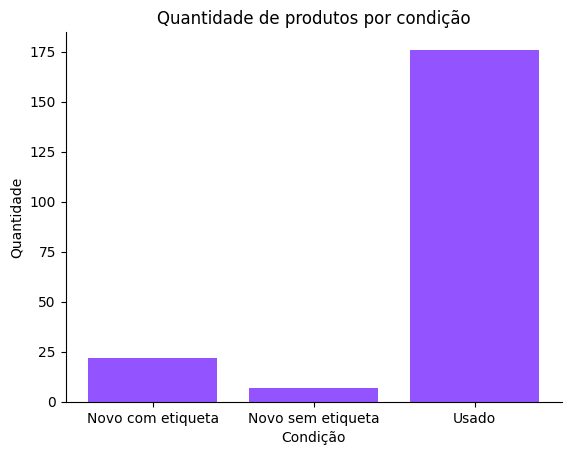

In [12]:
plt.bar(df_produto['Condicao'], df_produto['Quantidade'], color = '#9353FF')
plt.title('Quantidade de produtos por condição')
plt.xlabel('Condição')
plt.ylabel('Quantidade')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.show()

Agora precisamos ranquear os produtos que mais foram pedidos por **quantidade** para entender a necessidade de um estoque de produtos na loja.

In [13]:
sql_df('SELECT * FROM produto').head(3)

,produto_id,produto,preco,marca,sku,Condicao
0,21244,Oculos Lente Azulada,1120,D&g Dolce & Gabbana,209297,Usado
1,9981,Bolsa Coral Saco,4000,Givenchy,278612,Usado
2,84176,Camisa Xadrez Verde,310,Joe Fresh,322482,Usado


In [14]:
sql_df('SELECT * FROM itens_pedido').head(3)

,id_nf,produto_id,pedido_id,quantidade,valor_unitario,valor_total,Estado,frete
0,1,41518,341,3,260,780,BR-BA,156.0
1,2,4307,1174,5,6175,30875,BR-RJ,6175.0
2,3,22407,1399,3,200,600,BR-PB,120.0


In [15]:
query = '''SELECT PRODUTO.PRODUTO, SUM(ITENS_PEDIDO.QUANTIDADE) AS 'Quantidade'
FROM ITENS_PEDIDO, PRODUTO
WHERE ITENS_PEDIDO.PRODUTO_ID = PRODUTO.PRODUTO_ID
GROUP BY PRODUTO.PRODUTO
ORDER BY Quantidade ASC'''
df_prod_quant = sql_df(query)

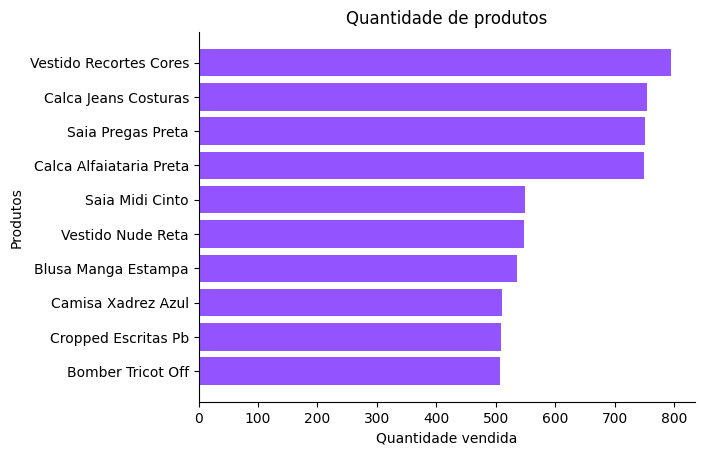

In [16]:
plt.barh(df_prod_quant['produto'][-10:], df_prod_quant['Quantidade'][-10:], color = '#9353FF')
plt.title('Quantidade de produtos')
plt.xlabel('Quantidade vendida')
plt.ylabel('Produtos')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.show()

### DESAFIO 1

* 1 - Calcular a receita total obtida com a venda de itens. Na tabela itens_pedidos, o valor total dos itens representa o cálculo da quantidade pelo valor unitário e pode ser considerado como a receita da venda.

* 2 -Análisar visa identificar quais as 15 marcas que foram as mais pedidas por quantidades de venda. Busque mostrar essa lista em uma visualização, além de expor o nome das marcas.

In [17]:
query = '''SELECT produto_id,
valor_total + frete AS Receita
FROM ITENS_PEDIDO
GROUP BY produto_id
ORDER BY Receita DESC'''
df_receita = sql_df(query)
df_receita

,produto_id,Receita
0,3865,39000.0
1,4307,37050.0
2,89100,30240.0
3,17990,27360.0
4,9981,24000.0
...,...,...
200,84743,144.0
201,58245,144.0
202,48872,144.0
203,95805,120.0


In [18]:
query = '''SELECT PRODUTO.PRODUTO, PRODUTO.MARCA, SUM(ITENS_PEDIDO.QUANTIDADE) AS 'Quantidade'
FROM ITENS_PEDIDO, PRODUTO
WHERE ITENS_PEDIDO.PRODUTO_ID = PRODUTO.PRODUTO_ID
GROUP BY PRODUTO.MARCA
ORDER BY Quantidade DESC'''
df_marca = sql_df(query)
df_marca

,produto,marca,Quantidade
0,Capa Fio Marrom,Zara,9545
1,Camisa Seda Pb,Mixed,5748
2,Macacao Malha Preto,Animale,4013
3,Blusa Malha Paete,Le Lis Blanc,2479
4,Calca Jeans Basica,Banana Republic,2045
...,...,...,...
112,Vestido Malha Cinza,All Saints Spitalfields,349
113,Regata Bicolor Alcinha,Express,342
114,Vestido Recortes Cores,Bcbgmaxzria,333
115,Blusa Malha Azul,Talie Nk,325


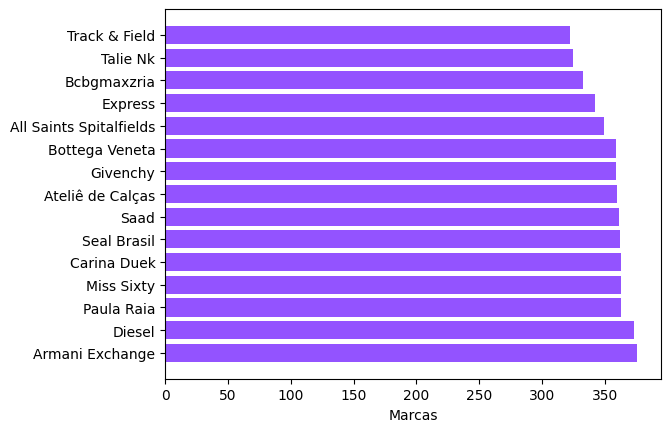

In [19]:
plt.barh(df_marca['marca'][-15:], df_marca['Quantidade'][-15:], color = '#9353FF')
plt.xlabel('Marcas')
plt.show()

# 3. Lidando com filtro

Vamos iniciar uma análise de desempenho do **time de vendedores** da Meteora. A intenção aqui é entender como se deram as vendas dos vendedores no **ano anterior** para que possam ser aplicadas promoções e bônus salarial para a equipe no ano atual da tabela que é 2021

Para entender o desempenho de vendas dos vendedores no ano de 2020, é preciso trabalhar com os dados que estão presentes apenas no ano de 2020.

In [20]:
sql_df('SELECT * FROM PEDIDOS').info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24527 entries, 0 to 24526
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   pedido_id    24527 non-null  int64 
 1   produto_id   24527 non-null  int64 
 2   vendedor_id  24527 non-null  int64 
 3   data_compra  24527 non-null  object
 4   total        24527 non-null  int64 
dtypes: int64(4), object(1)
memory usage: 958.2+ KB


In [21]:
query = '''SELECT VENDEDOR_ID, COUNT(*)
FROM PEDIDOS
WHERE strftime('%Y',data_compra) = '2020'
GROUP BY VENDEDOR_ID
'''
sql_df(query)

,vendedor_id,COUNT(*)
0,1,3427
1,2,3338
2,3,2782
3,4,2510
4,5,2488


# EXEMPLO DE FILTROS DE DATAS

In [22]:
## Selecionar dados do ano de 2019
query = '''
SELECT strftime('%m', data_compra) AS mes, COUNT(*) AS quantidade_vendas
FROM pedidos
WHERE strftime('%Y', data_compra) = '2019'
GROUP BY mes;
'''
vendas_19 = sql_df(query)
vendas_19

## Selecionar dados do ano de 2020
query = '''
SELECT strftime('%m', data_compra) AS mes, COUNT(*) AS quantidade_vendas
FROM pedidos
WHERE strftime('%Y', data_compra) = '2020'
GROUP BY mes;
'''
vendas_20 = sql_df(query)
vendas_20

,mes,quantidade_vendas
0,01,1271
1,02,1197
2,03,1280
3,04,1276
4,05,1206
5,06,896
6,07,984
7,08,1163
8,09,1221
9,10,1139


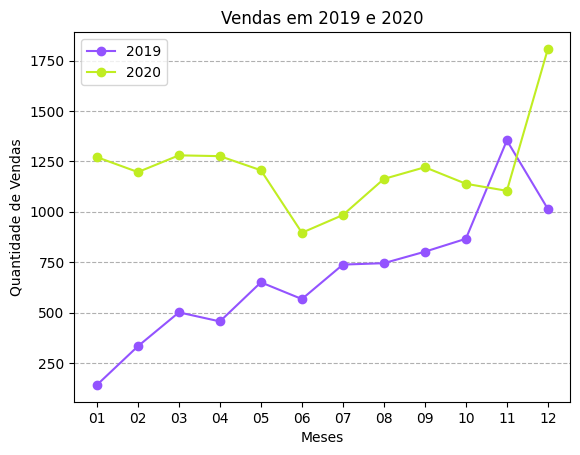

In [23]:
import matplotlib.pyplot as plt

# Plotar o gráfico de 2019 e 2020
plt.plot(vendas_19.mes.to_numpy(), vendas_19.quantidade_vendas.to_numpy(), marker='o', linestyle='-', color='#9353FF', label = '2019')
plt.plot(vendas_20.mes.to_numpy(), vendas_20.quantidade_vendas.to_numpy(), marker='o', linestyle='-', color='#C0ED22', label = '2020')

# Definir título e eixos
plt.title('Vendas em 2019 e 2020')
plt.xlabel('Meses')
plt.ylabel('Quantidade de Vendas')

# Adicionar a legenda
plt.legend()

# Adicionar grid horizontal
plt.grid(axis='y', linestyle='--')

# Exibir a figura
plt.show()

# CONTINUANDO PROJETO

In [24]:
query = '''SELECT VENDEDORES.NOME_VENDEDOR, COUNT(PEDIDOS.PEDIDO_ID) AS 'Quantidade vendas'
FROM PEDIDOS, VENDEDORES
WHERE strftime('%Y',data_compra) = '2020' AND VENDEDORES.VENDEDOR_ID = PEDIDOS.VENDEDOR_ID
GROUP BY VENDEDORES.NOME_VENDEDOR
ORDER BY COUNT(PEDIDOS.PEDIDO_ID) DESC;
'''
sql_df(query)

,nome_vendedor,Quantidade vendas
0,Ana Duarte,3427
1,Daniel Siqueira,3338
2,Nadia Oliveira,2782
3,Millena Pereira,2510
4,Paulo Calanca,2488


In [25]:
query = '''SELECT VENDEDORES.NOME_VENDEDOR,AVG(PEDIDOS.TOTAL) AS 'Valor médio por vendas'
FROM PEDIDOS, VENDEDORES
WHERE strftime('%Y',data_compra) = '2020' AND VENDEDORES.VENDEDOR_ID = PEDIDOS.VENDEDOR_ID
GROUP BY VENDEDORES.NOME_VENDEDOR
ORDER BY AVG(PEDIDOS.TOTAL) DESC;
'''
sql_df(query)

,nome_vendedor,Valor médio por vendas
0,Daniel Siqueira,1972.338526
1,Millena Pereira,1894.614343
2,Ana Duarte,1843.452582
3,Nadia Oliveira,1818.342200
4,Paulo Calanca,1813.469855


### DESAFIO 3

 * 1 exibir os 10 produtos mais vendidos durante o ano de 2019, que podem ser representados em uma tabela.

 * 2 Já o segundo será publicar a distribuição através dos meses da receita obtida em vendas no ano de 2021.

In [26]:
query = ''' SELECT PRODUTO.PRODUTO, SUM(ITENS_PEDIDO.QUANTIDADE) AS 'Quantidade'
FROM PRODUTO, ITENS_PEDIDO, PEDIDOS
WHERE strftime('%Y',PEDIDOS.DATA_COMPRA) = '2019' AND PEDIDOS.PEDIDO_ID = ITENS_PEDIDO.PEDIDO_ID AND ITENS_PEDIDO.PRODUTO_ID = PRODUTO.PRODUTO_ID
GROUP BY PRODUTO.PRODUTO
ORDER BY Quantidade DESC
LIMIT 10;
'''
sql_df(query)

,produto,Quantidade
0,Vestido Recortes Cores,287
1,Saia Pregas Preta,261
2,Calca Jeans Costuras,256
3,Blusa Manga Estampa,212
4,Camisa Xadrez Azul,210
5,Calca Alfaiataria Preta,209
6,Bomber Tricot Off,205
7,Cropped Escritas Pb,201
8,Conjunto Body Calca,200
9,Calca Estampa Flare,197


In [27]:
query = ''' SELECT ITENS_PEDIDO.VALOR_TOTAL, SUM(ITENS_PEDIDO.QUANTIDADE) AS 'Quantidade'
FROM PRODUTO, ITENS_PEDIDO, PEDIDOS
WHERE strftime('%Y',PEDIDOS.DATA_COMPRA) = '2021' AND PEDIDOS.PEDIDO_ID = ITENS_PEDIDO.PEDIDO_ID AND ITENS_PEDIDO.PRODUTO_ID = PRODUTO.PRODUTO_ID
GROUP BY PRODUTO.PRODUTO
ORDER BY Quantidade DESC
LIMIT 12;
'''
sql_df(query)

,valor_total,Quantidade
0,420,79
1,1080,72
2,1197,66
3,1250,60
4,210,59
5,2520,55
6,200,55
7,5600,54
8,1996,53
9,169,51


In [28]:
query = '''SELECT strftime('%m', data_compra) AS mes, SUM(total) AS receita
FROM pedidos
WHERE strftime('%Y', data_compra) = '2021'
GROUP BY mes;
'''
sql_df(query)

,mes,receita
0,01,2097109
1,02,1140729
2,03,51525


# 4. Avançando nas relações

A Meteora agora deseja incrementar as suas vendas no **estado de São Paulo (SP)**, por acreditar ser uma região mais propícia às vendas já que tem uma boa concentração de pessoas e mercado também.

Mas será que São Paulo já não rende muitas vendas em relação a outros estados?

In [30]:
query = ''' SELECT ESTADO, COUNT(*) AS Pedidos
FROM ITENS_PEDIDO
GROUP BY ESTADO
ORDER BY Pedidos DESC;
'''
sql_df(query)

,Estado,Pedidos
0,BR-MA,974
1,BR-DF,953
2,BR-MT,937
3,BR-GO,933
4,BR-PA,932
5,BR-AL,928
6,BR-PE,927
7,BR-RR,925
8,BR-RO,925
9,BR-RN,921


Uma das ações que a Meteora pretende seguir para as vendas em SP é escolher dois de seus vendedores para que eles **foquem suas vendas** lá. Para essa escolha é interessante ter os profissionais que **mais tenham vendido** para as pessoas da região.

In [38]:
query = '''SELECT PEDIDOS.VENDEDOR_ID, COUNT(*) AS quantidade_vendas
FROM PEDIDOS
JOIN ITENS_PEDIDO ON ITENS_PEDIDO.PEDIDO_ID = PEDIDOS.PEDIDO_ID
WHERE ITENS_PEDIDO.ESTADO = 'BR-SP'
GROUP BY PEDIDOS.VENDEDOR_ID
ORDER BY quantidade_vendas DESC;
'''
sql_df(query)

,vendedor_id,quantidade_vendas
0,2,190
1,5,182
2,3,181
3,1,180
4,4,157


In [39]:
query = '''SELECT VENDEDORES.NOME_VENDEDOR, COUNT(*) AS quantidade_vendas
FROM PEDIDOS
JOIN VENDEDORES ON PEDIDOS.VENDEDOR_ID = VENDEDORES.VENDEDOR_ID
JOIN ITENS_PEDIDO ON ITENS_PEDIDO.PEDIDO_ID = PEDIDOS.PEDIDO_ID
WHERE ITENS_PEDIDO.ESTADO = 'BR-SP'
GROUP BY VENDEDORES.NOME_VENDEDOR
ORDER BY quantidade_vendas DESC;
'''
sql_df(query)

,nome_vendedor,quantidade_vendas
0,Daniel Siqueira,190
1,Paulo Calanca,182
2,Nadia Oliveira,181
3,Ana Duarte,180
4,Millena Pereira,157


### DESAFIO 4

* listar as marcas vendidas em São Paulo por quantidade de pedidos;
* publicar os produtos que são mais vendidos na época de Natal no Brasil todo

In [52]:
query = '''SELECT PRODUTO.MARCA, COUNT(*) AS quantidade_vendas
FROM PEDIDOS, PRODUTO
JOIN VENDEDORES ON PEDIDOS.VENDEDOR_ID = VENDEDORES.VENDEDOR_ID
JOIN ITENS_PEDIDO ON ITENS_PEDIDO.PEDIDO_ID = PEDIDOS.PEDIDO_ID
WHERE ITENS_PEDIDO.ESTADO = 'BR-SP'
GROUP BY PRODUTO.MARCA
ORDER BY quantidade_vendas DESC
LIMIT 10;
'''
sql_df(query)

,marca,quantidade_vendas
0,Zara,20470
1,Mixed,12460
2,Animale,8010
3,Le Lis Blanc,5340
4,Banana Republic,4450
5,H&m,3560
6,Farm,3560
7,Tigresse,2670
8,Shoulder,2670
9,Sacada,2670


In [56]:
query = '''SELECT produto.PRODUTO, COUNT(*) AS quantidade_vendas
FROM ITENS_PEDIDO
JOIN produto ON produto.produto_id = ITENS_PEDIDO.produto_id
JOIN PEDIDOS ON PEDIDOS.PEDIDO_ID = ITENS_PEDIDO.PEDIDO_ID
WHERE strftime('%m',PEDIDOS.data_compra)= '12'
GROUP BY produto.produto
ORDER BY quantidade_vendas DESC
LIMIT 10;
'''
sql_df(query)

,produto,quantidade_vendas
0,Vestido Recortes Cores,30
1,Vestido Preto Franzido,26
2,Calca Jeans Costuras,26
3,Calca Alfaiataria Preta,26
4,Camisa Xadrez Azul,25
5,Saia Couro Tijolo,22
6,Cropped Listras Florzinhas,22
7,Calca Alfaiataria Rose,22
8,Vestido Longo Preto,21
9,Vestido Textura Branco,20
